# Modeling Customer Churn in Telecommunications Using Machine Learning
### *A case Study of SyriaTel*

## Introduction

Telecommunications industry connect people, families and businesses every day through calls, messages and internet. Every interaction generates a lot of data, and understanding this data can help companies improve services and keep customers happy. This project aims to explore the data, spot patterns, and even predict what might happen next. One common challenge for telecom companies is customer churn, when people decide to switch to a different service provider. In this project, we use SyriaTel’s customer data to uncover insights and build a model that can help the company identify at-risk customers and take steps to keep them.



## Business Problem
SyriaTel telecommunications company faces the main challenge of customer churn; where customers discontinue their services. Churn affects their revenue directly since acquiring new customers is significantly more expensive than retaining the existing customers. High churn rates reduce long term profitability of the business. The company needs to understand whether there are predictable patterns in customer behavior that signal an increased likelihood of churn. If these patterns are identified early, SyriaTel can take proactive measures such as targeted promotions, personalized incentives and improved m m mmm mcustomer care to retain customers with high churn rates. The main goal of this project is to build a binary classification model which accurately predicts customers who are most likely to churn, and identify the features that are important for predicting customer churn.

The objectives of this project are:

1.To Build a logistic regression model that accurately classifies customers as likely to churn or not churn based on historical customer data.

2.To identify key features that influence customer churn.

3.To assess model performance and reliability using appropriate metrics.

## Data Understanding
This project uses SyriaTel’s customer churn dataset, which contains information about their subscribers and whether or not they eventually churned. The data is sourced from Kaggle, a public data repository that hosts a wide range of datasets for research and academic purposes. The dataset is available as a **CSV** file and can be accessed [here](https://www.kaggle.com/datasets/becksddf/churn-in-telecoms-dataset).


In [1]:
#loading the data
import pandas as pd
data = pd.read_csv('Data/Telecom.dataset.csv')
data


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


The data is structured with 3333 rows and 21 columns.
The target variable is **Churn**, with two possible outcomes: 

`False` – the customer stayed  
`True` – the customer left the service.

The dataset has several features,**predictors**, that can be widely grouped as: 

- *Customer Identification*:  state, account length, area code, phone number

- *Service Plans*:  international plan, voice mail plan

- *Usage*:  number vmail messages, total day minutes, total day calls, total eve minutes, total eve calls, total night minutes, total night calls, total intl minutes, total intl calls

- *Charges*:  total day charge, total eve charge, total night charge, total intl charge

- *Customer Care*:  customer service calls.



In [2]:
# checkingm for missing values
data.isna().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

From the above output, the SyriaTel dataset is complete with no missing values.

In [3]:
 #checking for duplicates 
data.duplicated(subset='phone number').value_counts()

False    3333
dtype: int64

For telecommunications company, every customer has a unique phone number, which can serve as a unique identifier for each record in the dataset. The output above shows that all 3333 rows are unique in the phone number column. Hence there is no duplicates in the dataset.

In [4]:
#summary of the dataframe
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

The area code variable is stored as an integer, however, it represents geographic regions and does not carry numerical significance. Therefore, it will be converted to an object data type to reflect its categorical nature.

In [5]:
# Convert area_code from integer to object datatype
data['area code'] = data['area code'].astype('object')

In [6]:
#confirm data type
data['area code'].dtype

dtype('O')

For modeling purposes, the features in the dataset will be grouped as categorical or numerical;

`Categorical features` include area code, international plan, and voice mail plan.

`Numerical features` include account length, number of vmail messages, total day minutes, total day calls, total eve minutes, total eve calls, total night minutes, total night calls, total intl minutes, total intl calls, and customer service calls.

## Exploratory data analysis

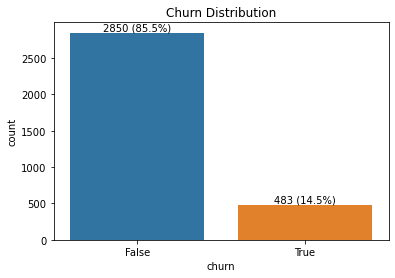

In [7]:
# showing churn Distribution
import seaborn as sns
import matplotlib.pyplot as plt

# Count churn values
churn_counts = data['churn'].value_counts()
churn_percent = data['churn'].value_counts(normalize=True) * 100

# Plot with counts
ax = sns.countplot(x='churn', data=data)

# Annotate with percentages
for p, count, perc in zip(ax.patches, churn_counts, churn_percent):
    ax.annotate(f'{count} ({perc:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

plt.title("Churn Distribution")
plt.show()



The chart shows the distribution of our target variable, Churn. The `False` bar is much taller, representing 85.5% of the records, confirming that most customers stayed. The `True` bar is shorter,14.5%, showing that only a small fraction of customers left. The chart reveals a class imbalance in the dataset. 

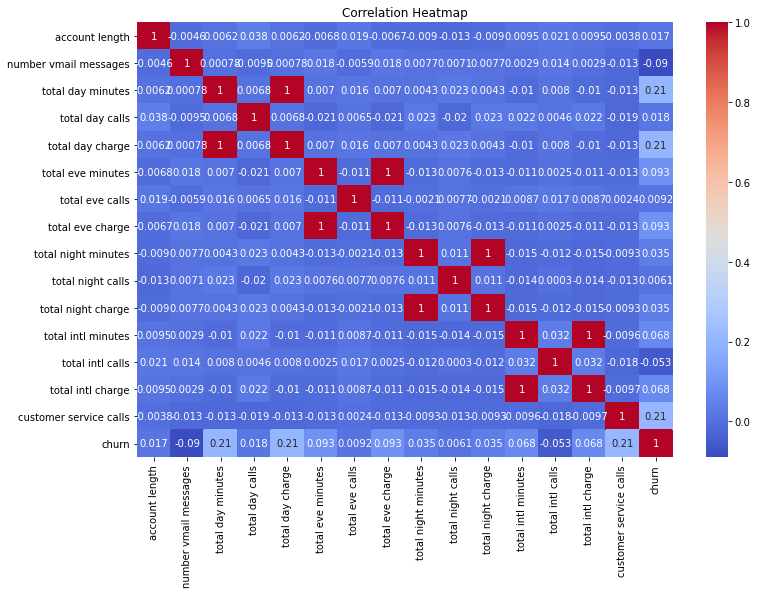

In [8]:
#Checking for multicollinearity
corr = data.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap shows pairwise correlation coefficients between numerical variables in the dataset. Total day minutes and total day charge show a perfect correlation of 1. The same is observed for total evening minutes, total night minutes total international minutes and their corresponding charges. This is becauses charges are calculated directly from minutes spent on the call. we shall drop the charges columns to avoid multicollinearity.

Customer service calls has a high positive correlation with churn. This indicate that customers who contact customer service more frequently are more likely to leave. 

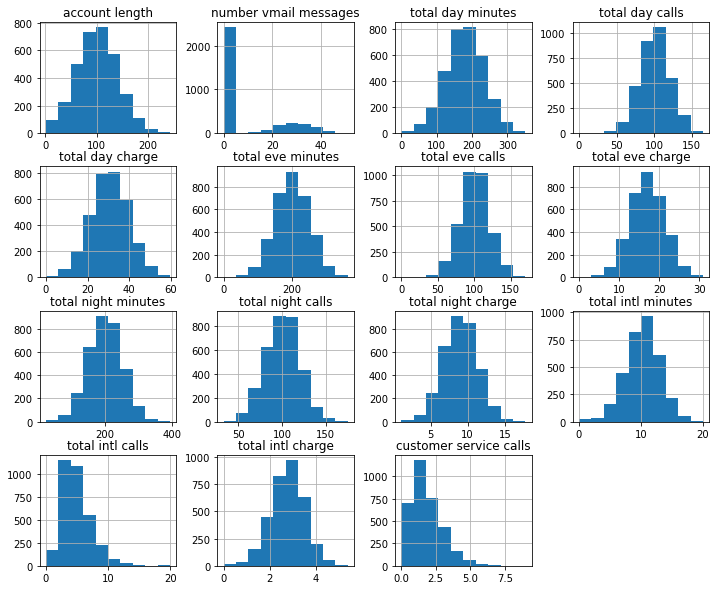

In [9]:
#Distribution of predictor variables
data.drop(columns='churn').hist(figsize=(12,10));


The histogram grid illustrates the distribution of the various numerical variables in the dataset. The variables are measured on different scales and exhibit non-normal (skewed) distributions. The observed variation in scales and the presence of skewed distributions indicate that the data require preprocessing,that is scaling and standardization, before modeling.

## Modeling


### Importing required libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve


### Defining Target and Independent variables
For this analysis, `churn` is defined as the target variable (`y`), and the other features in the dataset are predictor variables (`X`) used to model customer churn.

In [11]:
#Defining X and y
y = data["churn"]
X = data.drop(['churn','phone number','state', 'total day charge','total eve charge','total night charge','total intl charge'
], axis=1)


### Train-Test Split
The dataset is split into training and testing sets. We will use a `random_state=42` and `test_size=0.2`.



In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

### Preprocessing (Training set)

In [13]:
#Dealing with categorical data
categorical_cols = ['area code','international plan','voice mail plan']
X_train_categorical = X_train[categorical_cols].copy()

ohe = OneHotEncoder(sparse=False,drop='first')

ohe.fit(X_train_categorical)
X_train_ohe = pd.DataFrame(ohe.transform(X_train_categorical),
                                index = X_train.index,
                                columns = ohe.get_feature_names(categorical_cols))
X_train_ohe


,area code_415,area code_510,international plan_yes,voice mail plan_yes
817,0.0,1.0,0.0,0.0
1373,1.0,0.0,0.0,0.0
679,1.0,0.0,1.0,0.0
56,1.0,0.0,0.0,0.0
1993,0.0,1.0,0.0,0.0
...,...,...,...,...
1095,0.0,1.0,0.0,0.0
1130,1.0,0.0,0.0,0.0
1294,0.0,0.0,0.0,0.0
860,1.0,0.0,0.0,0.0


In [14]:
#normalization
numeric_cols = [
    'account length', 
    'number vmail messages',
    'total day minutes', 
    'total day calls',
    'total eve minutes', 
    'total eve calls',
    'total night minutes', 
    'total night calls',
    'total intl minutes', 
    'total intl calls',
    'customer service calls'
]
X_train_numeric = X_train[numeric_cols].copy()
scaler = MinMaxScaler()

scaler.fit(X_train_numeric)
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_numeric),
    index = X_train_numeric.index,
    columns = X_train_numeric.columns
)

X_train_scaled

,account length,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls
817,1.000000,0.000000,0.266801,0.459259,0.450096,0.370588,0.648198,0.598592,0.330,0.315789,0.222222
1373,0.442149,0.000000,0.314187,0.555556,0.532582,0.647059,0.499462,0.422535,0.205,0.210526,0.444444
679,0.305785,0.000000,0.631246,0.355556,0.899093,0.652941,0.497041,0.500000,0.435,0.473684,0.111111
56,0.578512,0.000000,0.356979,0.503704,0.494913,0.364706,0.316299,0.669014,0.400,0.105263,0.111111
1993,0.351240,0.000000,0.613728,0.488889,0.732197,0.452941,0.513179,0.542254,0.225,0.157895,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
1095,0.433884,0.000000,0.780586,0.666667,0.546054,0.482353,0.370091,0.204225,0.300,0.157895,0.111111
1130,0.500000,0.000000,0.093337,0.237037,0.497113,0.523529,0.614309,0.176056,0.635,0.105263,0.111111
1294,0.268595,0.000000,0.244113,0.340741,0.720374,0.652941,0.434104,0.647887,0.460,0.263158,0.111111
860,0.694215,0.000000,0.507180,0.600000,0.481716,0.764706,0.552448,0.415493,0.495,0.315789,0.222222


In [15]:
X_train = pd.concat([X_train_scaled, X_train_ohe], axis=1)
X_train

,account length,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls,area code_415,area code_510,international plan_yes,voice mail plan_yes
817,1.000000,0.000000,0.266801,0.459259,0.450096,0.370588,0.648198,0.598592,0.330,0.315789,0.222222,0.0,1.0,0.0,0.0
1373,0.442149,0.000000,0.314187,0.555556,0.532582,0.647059,0.499462,0.422535,0.205,0.210526,0.444444,1.0,0.0,0.0,0.0
679,0.305785,0.000000,0.631246,0.355556,0.899093,0.652941,0.497041,0.500000,0.435,0.473684,0.111111,1.0,0.0,1.0,0.0
56,0.578512,0.000000,0.356979,0.503704,0.494913,0.364706,0.316299,0.669014,0.400,0.105263,0.111111,1.0,0.0,0.0,0.0
1993,0.351240,0.000000,0.613728,0.488889,0.732197,0.452941,0.513179,0.542254,0.225,0.157895,0.000000,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,0.433884,0.000000,0.780586,0.666667,0.546054,0.482353,0.370091,0.204225,0.300,0.157895,0.111111,0.0,1.0,0.0,0.0
1130,0.500000,0.000000,0.093337,0.237037,0.497113,0.523529,0.614309,0.176056,0.635,0.105263,0.111111,1.0,0.0,0.0,0.0
1294,0.268595,0.000000,0.244113,0.340741,0.720374,0.652941,0.434104,0.647887,0.460,0.263158,0.111111,0.0,0.0,0.0,0.0
860,0.694215,0.000000,0.507180,0.600000,0.481716,0.764706,0.552448,0.415493,0.495,0.315789,0.222222,1.0,0.0,0.0,0.0


In [16]:
#fit baseline model 
logreg = LogisticRegression(fit_intercept=False)
Training_model_log = logreg.fit(X_train, y_train)
Training_model_log

LogisticRegression(fit_intercept=False)

In [17]:
y_train_preds = logreg.predict(X_train)

accuracy_train = accuracy_score(y_train, y_train_preds)
accuracy_train

0.8604651162790697

### Preprocessing (Test set)

In [18]:
#Dealing with categorical data for test set
X_test_categorical = X_test[categorical_cols].copy()

X_test_ohe = pd.DataFrame(ohe.transform(X_test_categorical),
                                index = X_test.index,
                                columns = ohe.get_feature_names(categorical_cols))
X_test_ohe







,area code_415,area code_510,international plan_yes,voice mail plan_yes
438,0.0,1.0,0.0,0.0
2674,1.0,0.0,0.0,0.0
1345,1.0,0.0,0.0,0.0
1957,0.0,0.0,0.0,0.0
2148,0.0,0.0,0.0,0.0
...,...,...,...,...
2577,0.0,1.0,0.0,0.0
2763,0.0,0.0,0.0,1.0
3069,1.0,0.0,0.0,1.0
1468,0.0,1.0,0.0,1.0


In [19]:
#Normalization
X_test_numeric = X_test[numeric_cols].copy()
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_numeric),
    index = X_test_numeric.index,
    columns = X_test_numeric.columns
)

X_test_scaled


,account length,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls
438,0.462810,0.000000,0.437679,0.466667,0.908991,0.623529,0.447015,0.633803,0.675,0.157895,0.111111
2674,0.272727,0.000000,0.305859,0.644444,0.597745,0.729412,0.444325,0.760563,0.640,0.315789,0.000000
1345,0.400826,0.000000,-0.007467,-0.222222,0.438823,0.764706,0.387036,0.387324,0.340,0.052632,0.444444
1957,0.603306,0.000000,0.603676,0.362963,0.561177,0.535294,0.357719,0.563380,0.510,0.105263,0.111111
2148,0.392562,0.000000,0.406088,0.533333,0.617817,0.429412,0.550027,0.408451,0.500,0.368421,0.111111
...,...,...,...,...,...,...,...,...,...,...,...
2577,0.644628,0.000000,0.524124,0.459259,0.585648,0.500000,0.465035,0.366197,0.425,0.263158,0.222222
2763,0.475207,0.372549,0.439690,0.548148,0.509761,0.694118,0.455890,0.584507,0.410,0.105263,0.333333
3069,0.607438,0.509804,0.448306,0.451852,0.441298,0.747059,0.524744,0.387324,0.495,0.157895,0.111111
1468,0.305785,0.529412,0.329983,0.533333,0.568600,0.747059,0.460463,0.570423,0.210,0.368421,0.333333


In [20]:
X_test = pd.concat([X_test_scaled, X_test_ohe], axis = 1)
X_test

,account length,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls,area code_415,area code_510,international plan_yes,voice mail plan_yes
438,0.462810,0.000000,0.437679,0.466667,0.908991,0.623529,0.447015,0.633803,0.675,0.157895,0.111111,0.0,1.0,0.0,0.0
2674,0.272727,0.000000,0.305859,0.644444,0.597745,0.729412,0.444325,0.760563,0.640,0.315789,0.000000,1.0,0.0,0.0,0.0
1345,0.400826,0.000000,-0.007467,-0.222222,0.438823,0.764706,0.387036,0.387324,0.340,0.052632,0.444444,1.0,0.0,0.0,0.0
1957,0.603306,0.000000,0.603676,0.362963,0.561177,0.535294,0.357719,0.563380,0.510,0.105263,0.111111,0.0,0.0,0.0,0.0
2148,0.392562,0.000000,0.406088,0.533333,0.617817,0.429412,0.550027,0.408451,0.500,0.368421,0.111111,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2577,0.644628,0.000000,0.524124,0.459259,0.585648,0.500000,0.465035,0.366197,0.425,0.263158,0.222222,0.0,1.0,0.0,0.0
2763,0.475207,0.372549,0.439690,0.548148,0.509761,0.694118,0.455890,0.584507,0.410,0.105263,0.333333,0.0,0.0,0.0,1.0
3069,0.607438,0.509804,0.448306,0.451852,0.441298,0.747059,0.524744,0.387324,0.495,0.157895,0.111111,1.0,0.0,0.0,1.0
1468,0.305785,0.529412,0.329983,0.533333,0.568600,0.747059,0.460463,0.570423,0.210,0.368421,0.333333,0.0,1.0,0.0,1.0


In [21]:
#accuracy
y_test_preds = logreg.predict(X_test)

accuracy_test = accuracy_score(y_test, y_test_preds)
accuracy_test

0.8470764617691154

Accuracy provides an overall measure of performance, additional metrics such as precision and recall are considered to better assess the model’s ability to correctly identify churners in an imbalanced dataset.

In [22]:
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_preds))


Confusion Matrix:
[[553  13]
 [ 89  12]]


#### Recall and Precision for baseline model

In [23]:
# Recall for churn (True = churners)
recall = recall_score(y_test, y_test_preds)
print("Recall:", recall)

# Precision for churn
precision = precision_score(y_test, y_test_preds)
print("Precision:", precision)

Recall: 0.1188118811881188
Precision: 0.48


The baseline logistic regression achieves an overall accuracy of about 84%. This seems high and would suggest the model is performing well. 
Recall measures the proportion of actual churners that the model correctly identifies. In the baseline model, recall is only about 12%, meaning that the model detects just a small fraction of customers who actually churn. This extremely low recall indicates that most churners go undetected, which poses a significant risk to the business due to potential lost revenue from unretained customers. 

While baseline accuracy seems acceptable, the model fails to detect most churners. This clearly indicates the need for model improvement.

### Handling class imbalance

In [24]:
# handling imbalance using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
pd.Series(y_train_smote).value_counts()


True     2284
False    2284
Name: churn, dtype: int64

In [25]:
# Initialize model
improved_model = LogisticRegression(solver='liblinear', max_iter=1000)

# Fit model on SMOTE data
improved_model.fit(X_train_smote, y_train_smote)
y_pred = improved_model.predict(X_test)

In [26]:
#Accuracy for improved model
accuracy_improvedmodel = accuracy_score(y_test, y_pred)
accuracy_improvedmodel

0.7766116941529235

#### Recall and Precision for improved model

In [27]:
# Recall for improved model
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Recall: 0.7722772277227723
Precision: 0.38235294117647056


The model achieves a recall of approximately 77%, meaning it correctly identifies about 77% of customers who actually churn. This represents a substantial improvement from the baseline recall of about 12%, indicating that the model is now much more effective at detecting customers who are at risk of leaving. High recall is more valuable than high precision in churn prediction, as it target our goal.

###  ROC Curve
The ROC curve is a graphical representation that evaluates a classification model’s performance across different thresholds. It plots the True Positive Rate (Recall) against the False Positive Rate, showing how well the model balances correctly identifying churners versus incorrectly flagging non-churners. The Area Under the Curve (AUC) provides a summary metric, with higher values indicating stronger discrimination between the two classes.



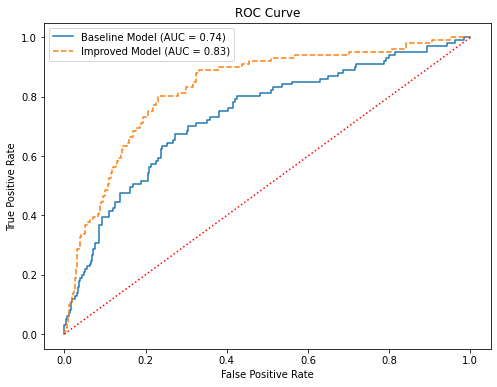

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities for baseline and improved model
y_probs_baseline = logreg.predict_proba(X_test)[:, 1]        
y_probs_improved = improved_model.predict_proba(X_test)[:, 1]

# ROC curve for baseline
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_probs_baseline)
auc_baseline = roc_auc_score(y_test, y_probs_baseline)

# ROC curve for improved model
fpr_improved, tpr_improved, _ = roc_curve(y_test, y_probs_improved)
auc_improved = roc_auc_score(y_test, y_probs_improved)

# Plot ROC curves
plt.figure(figsize=(8,6))
plt.plot(fpr_baseline, tpr_baseline, label=f'Baseline Model (AUC = {auc_baseline:.2f})')
plt.plot(fpr_improved, tpr_improved, label=f'Improved Model (AUC = {auc_improved:.2f})', linestyle='--')
plt.plot([0,1], [0,1], color='red', linestyle=':')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

The baseline logistic regression model achieved an AUC of 0.74, reflecting a moderate ability to distinguish churners from non-churners. The improved model’s AUC is 0.83. This demonstrates a substantial enhancement in the model’s capacity to detect customers likely to churn. The model with a higher AUC is better as it enables the company to more precisely identify at-risk customers, strengthen retention initiatives, and minimize potential revenue losses.

## Conclusion
This project developed a logistic regression model to identify customers at risk of churning for SyriaTel. The baseline model did not address the class imbalance. While the model achieved a high overall accuracy of approximately 84%, its recall was very low, about 12%, indicating that it failed to detect most of the actual churners. 

To improve performance, we applied SMOTE to balance the training dataset and retrained the logistic regression model using the liblinear solver. The improved model demonstrated significant gains, achieving a recall of about 77%, precision of about 38% and an AUC increase from 0.74 to 0.83, showing a much better ability to identify customers likely to churn.

Analysis of the features using correlation heatmap revealed that customer service calls is a strong predictor of churn. Customers who frequently contacted customer service were more likely to leave, suggesting that dissatisfaction is a key driver of churn.


